In [1]:
import pandas as pd 
df=pd.read_csv("amazon.csv")
print(df.shape)
print(df.head())

(1465, 16)
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349           

In [2]:
print("shape:",df.shape)
print("\nColumn names:",df.columns.tolist())
print("\nMissing values:\n",df.isnull().sum())

shape: (1465, 16)

Column names: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

Missing values:
 product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


C:\Users\sagar\AppData\Local\Temp\ipykernel_24572\667507874.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


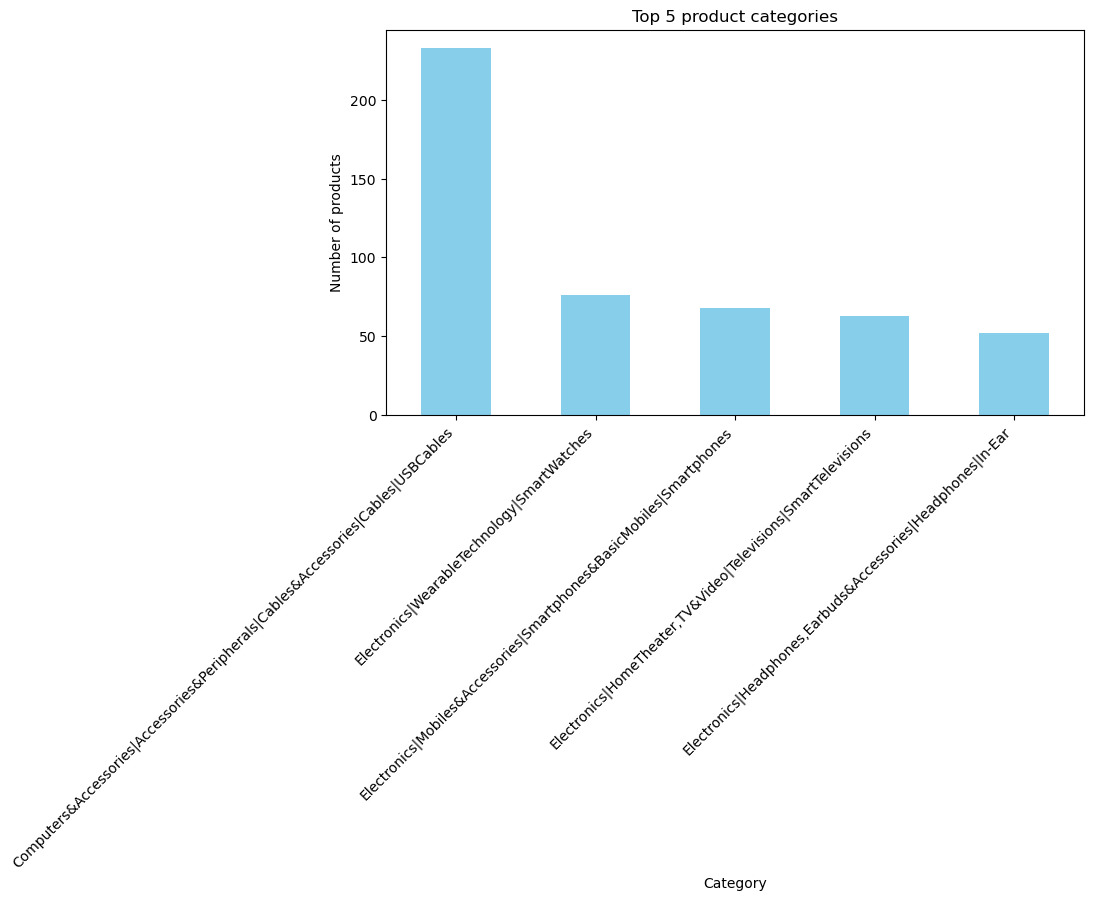

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
top_cat=df['category'].value_counts().head(5)
plt.figure(figsize=(9,5))
top_cat.plot(kind='bar',color='skyblue')
plt.title("Top 5 product categories")
plt.xlabel("Category")
plt.ylabel("Number of products")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [4]:
df['discounted_price'].head()

0    ₹399
1    ₹199
2    ₹199
3    ₹329
4    ₹154
Name: discounted_price, dtype: object

In [5]:
df['discounted_price']=df['discounted_price'].replace('[₹,]','',regex=True).astype(float)
df['discount_percentage']=df['discount_percentage'].replace('[%]','', regex=True).astype(float)


In [6]:
avg_price=df['discounted_price'].mean()
print("Average Price:",round(avg_price,2))


Average Price: 3125.31


In [7]:
cheapest=df.loc[df['discounted_price'].idxmin()]
print("\nCheapest Product:",cheapest['product_name'])
print("Price:",cheapest['discounted_price'])

costliest=df.loc[df['discounted_price'].idxmax()]
print("\nCostliest Product:",costliest['product_name'])
print("Price:",costliest['discounted_price'])






Cheapest Product: GIZGA essentials Universal Silicone Keyboard Protector Skin for 15.6-inches Laptop (5 x 6 x 3 inches)
Price: 39.0

Costliest Product: Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black)
Price: 77990.0


In [8]:
top_discounts=df.nlargest(5,'discount_percentage')[['product_name','discount_percentage','discounted_price']]
print("Top 5 products with Highest Discount:")
print(top_discounts)

Top 5 products with Highest Discount:
                                          product_name  discount_percentage  \
695  rts [2 Pack] Mini USB C Type C Adapter Plug, T...                 94.0   
334  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...                 91.0   
364  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...                 91.0   
368  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...                 91.0   
372  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...                 91.0   

     discounted_price  
695             294.0  
334            1799.0  
364            1799.0  
368            1799.0  
372            1799.0  


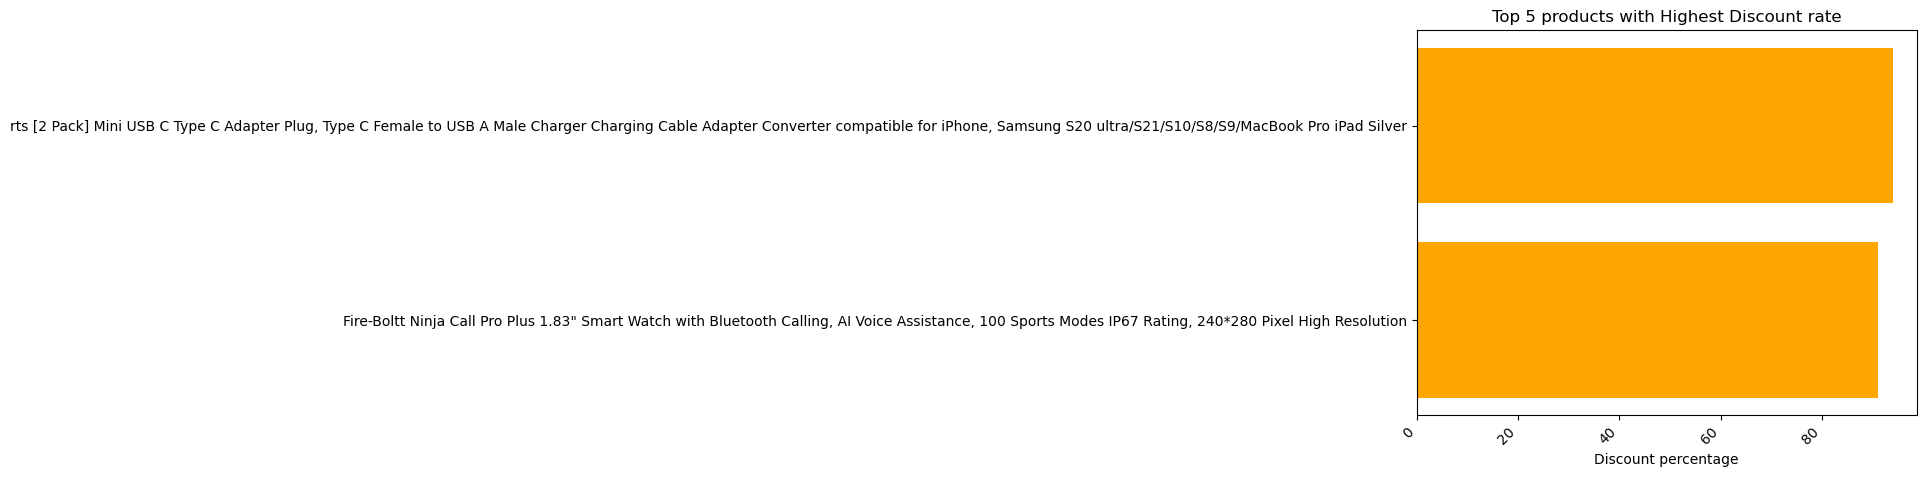

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.barh(top_discounts['product_name'],top_discounts['discount_percentage'],color='orange')
plt.title("Top 5 products with Highest Discount rate")
plt.xlabel('Discount percentage')
plt.gca().invert_yaxis()
plt.xticks(rotation=45,ha='right')
plt.subplots_adjust(left=0.4)
plt.show()

###  The Highest discount found is 94% on accessories and smart watches. 

In [10]:
df_clean=df.dropna(subset=['rating','rating_count']).copy()
                           
df_clean['rating']=pd.to_numeric(df_clean['rating'],errors='coerce')
df_clean['rating_count']=pd.to_numeric(df_clean['rating_count'],errors='coerce')   
                                 
avg_rating=df_clean['rating'].mean()
print("Average Rating:",round(avg_rating,2))    
                                 
top_rated=df_clean[df_clean['rating_count']>=100].nlargest(5,'rating')[['product_name','rating','rating_count']    ]    
print("\nTop 5 Highest Rated Products (min 100 reviews):")
print(top_rated)                                
                                 
                                


Average Rating: 4.1

Top 5 Highest Rated Products (min 100 reviews):
                                           product_name  rating  rating_count
571   WeCool S5 Long Selfie Stick, with Large Reinfo...     4.6         245.0
1007  WeCool S5 Long Selfie Stick, with Large Reinfo...     4.6         245.0
1119  Lint Remover Woolen Clothes Lint Extractor Bat...     4.6         124.0
1289  Aquadpure Copper + Mineral RO+UV+UF 10 to 12 L...     4.6         124.0
20    Duracell USB Lightning Apple Certified (Mfi) B...     4.5         815.0


###  Average rating across products with valid data is 4.1/5.

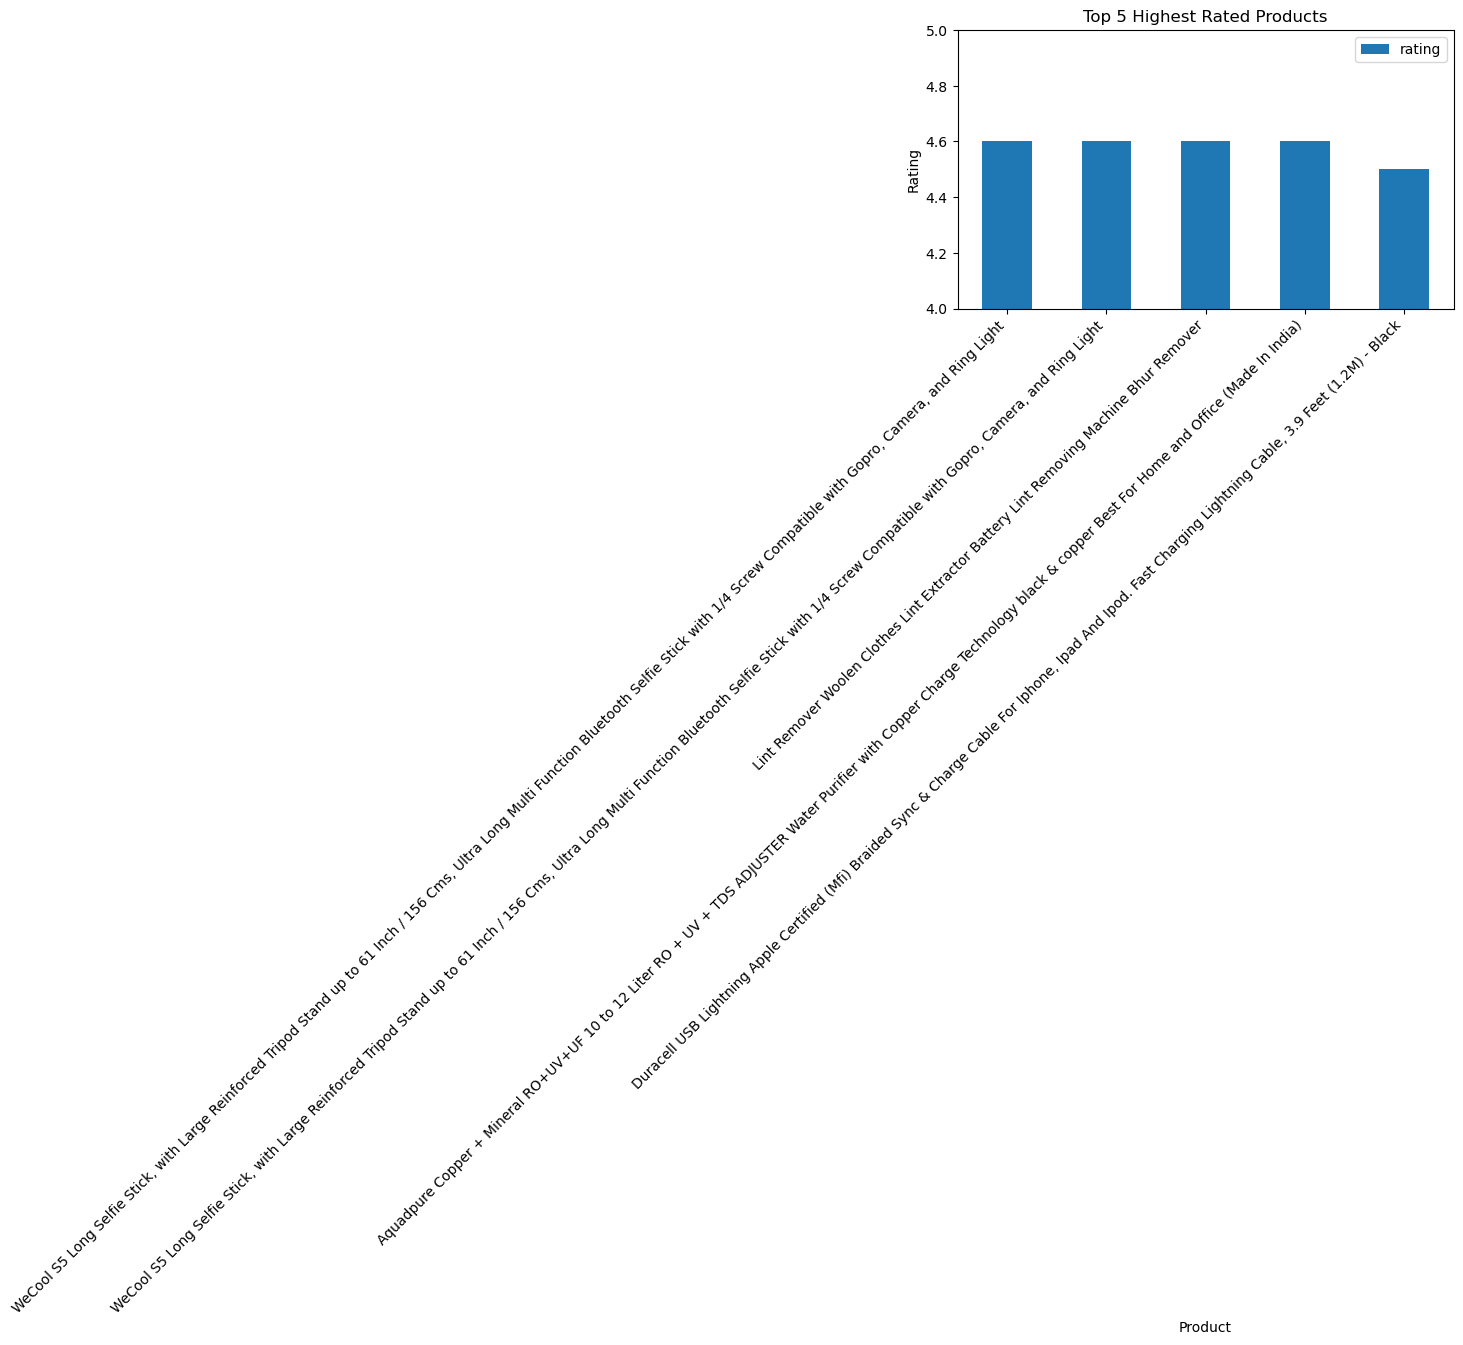

In [11]:
import matplotlib.pyplot as plt

top_rated.plot(kind='bar',x='product_name',y='rating',legend='False')
plt.title('Top 5 Highest Rated Products' )
plt.xlabel('Product')
plt.ylabel('Rating')
plt.xticks(rotation=45,ha='right')
plt.subplots_adjust(bottom=0.3)
plt.ylim(4.0,5.0)
plt.show()

### Project  Summary & Skills 

**Key Findings:**
Products with 100+ customer reviews have an average rating of **4.1/5**, indicating strong overall satisfaction.The top 5 products are all rated above 4.5.


**Technical Skills Used:**
- **Python & Pandas**: Data cleaning, filtering, aggregation, and analysis 
- **Matplotlib**:Created visualizations to communicate insights clearly 
- **SQL**:Familiar with writing queries for filtering,aggregation, and joins.Prototyped analysis in SQLite 